# ۶. تحلیل مزیت خانه و مهمان با اعمال قدرت تیم‌ها

در این نوت‌بوک اثر مزیت خانه با در نظر گرفتن اختلاف قدرت تیم‌ها، Elo و قدرت کلی تیم‌ها بررسی می‌شود. فرض اصلی این است که هرچه تیمی از لحاظ رتبه و قدرت برتری داشته باشد، تعادل بازی بیشتر به نفع آن تیم می‌چرخد و اثر متقابل مزیت خانه کاهش می‌یابد.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "DataSet2").is_dir())
ANALYSIS_ROOT = ROOT / "UCL_Analysis2"
OUTPUT = ANALYSIS_ROOT / "Output"
sys.path.insert(0, str(ANALYSIS_ROOT / "src"))
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
print("Repository root:", ROOT)


Repository root: d:\progrraming\university\Data mining\Article


## 1. آماده‌سازی داده‌ها

برای هر مسابقه، اختلاف قدرت پیش از بازی به‌صورت `elo_diff_pre` و `alltime_elo_proxy_diff` محاسبه می‌شود. این تفاوت‌ها نشان می‌دهند که چه مقدار مزیت خانه یا مهمان از نظر کیفیت تیم‌ها تعدیل شده است.

In [2]:
analysis = pd.read_csv(OUTPUT / "detailed_matches_enriched.csv").copy()
analysis["date"] = pd.to_datetime(analysis["date"])
analysis["home_win"] = analysis["result"].eq("H").astype(int)
analysis["away_win"] = analysis["result"].eq("A").astype(int)
analysis["draw"] = analysis["result"].eq("D").astype(int)
analysis["elo_diff_pre_100"] = analysis["elo_diff_pre"] / 100.0
analysis["alltime_elo_proxy_diff_100"] = analysis["alltime_elo_proxy_diff"] / 100.0
analysis["strength_gap_abs"] = analysis["alltime_elo_proxy_diff"].abs()
analysis[["date", "home_team", "away_team", "elo_diff_pre", "alltime_elo_proxy_diff", "result"]].head()


,date,home_team,away_team,elo_diff_pre,alltime_elo_proxy_diff,result
0,2005-09-13,AC Milan,Fenerbahçe,0.0,159.4,H
1,2005-09-13,PSV Eindhoven,FC Schalke 04,0.0,-29.4,H
2,2005-09-13,Olympiakos Piraeus,Rosenborg BK,0.0,19.1,A
3,2005-09-13,Olympique Lyon,Real Madrid,0.0,-94.2,H
4,2005-09-13,Chelsea FC,RSC Anderlecht,0.0,135.5,H


## 2. بررسی نرخ بردها بر اساس اختلاف Elo

In [3]:
bins = np.arange(-10, 11, 1)
analysis["elo_bin"] = pd.cut(analysis["elo_diff_pre"], bins=bins, include_lowest=True, right=False)
elo_summary = analysis.groupby("elo_bin", observed=False).agg(
    matches=("result", "size"),
    home_win_rate=("home_win", "mean"),
    away_win_rate=("away_win", "mean"),
    draw_rate=("draw", "mean"),
    mean_elo_diff=("elo_diff_pre", "mean"),
).reset_index().dropna(subset=["mean_elo_diff"])
elo_summary["home_minus_away"] = elo_summary["home_win_rate"] - elo_summary["away_win_rate"]
elo_summary.head(15)


,elo_bin,matches,home_win_rate,away_win_rate,draw_rate,mean_elo_diff,home_minus_away
0,"[-10, -9)",19,0.473684,0.210526,0.315789,-9.610947,0.263158
1,"[-9, -8)",14,0.357143,0.428571,0.214286,-8.551500,-0.071429
2,"[-8, -7)",11,0.727273,0.000000,0.272727,-7.424545,0.727273
3,"[-7, -6)",10,0.500000,0.300000,0.200000,-6.497800,0.200000
4,"[-6, -5)",10,0.600000,0.400000,0.000000,-5.405000,0.200000
5,"[-5, -4)",10,0.500000,0.300000,0.200000,-4.685900,0.200000
6,"[-4, -3)",7,0.142857,0.428571,0.428571,-3.373857,-0.285714
7,"[-3, -2)",8,0.375000,0.375000,0.250000,-2.477750,0.000000
8,"[-2, -1)",11,0.272727,0.363636,0.363636,-1.383636,-0.090909
9,"[-1, 0)",11,0.727273,0.090909,0.181818,-0.616273,0.636364


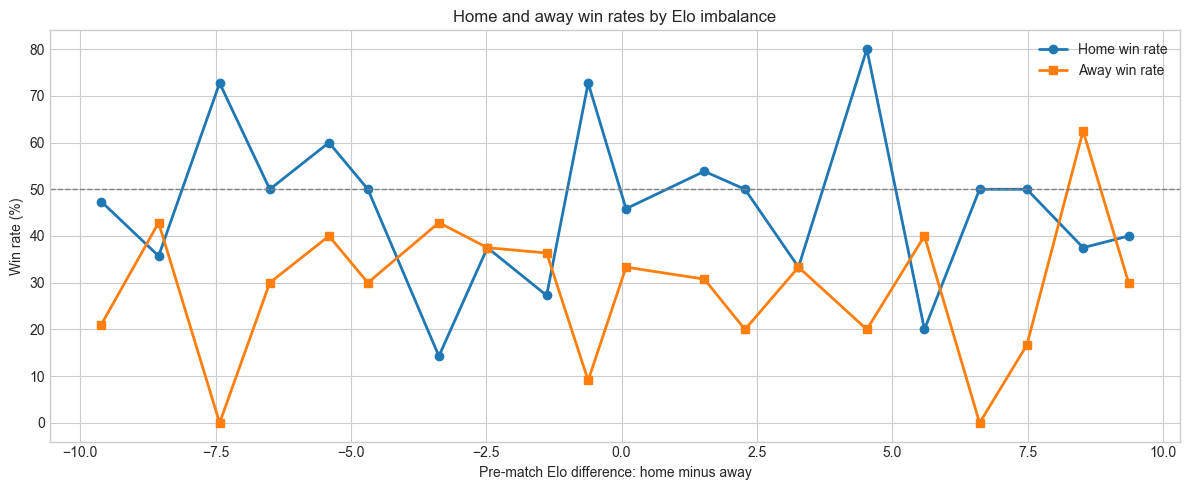

In [4]:
plot_df = elo_summary.sort_values("mean_elo_diff")
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["mean_elo_diff"], plot_df["home_win_rate"] * 100, marker="o", linewidth=2, label="Home win rate")
ax.plot(plot_df["mean_elo_diff"], plot_df["away_win_rate"] * 100, marker="s", linewidth=2, label="Away win rate")
ax.axhline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Pre-match Elo difference: home minus away")
ax.set_ylabel("Win rate (%)")
ax.set_title("Home and away win rates by Elo imbalance")
ax.legend()
fig.tight_layout()
plt.show()


## 3. اثر مزیت خانه در سطوح مختلف اختلاف قدرت تیم‌ها

In [6]:
def summarize_by_strength_gap(frame, gap_col):
    frame = frame.copy()
    frame["gap_bin"] = pd.qcut(frame[gap_col].abs(), q=5, duplicates="drop")
    out = frame.groupby("gap_bin", observed=False).agg(
        matches=("result", "size"),
        home_win_rate=("home_win", "mean"),
        away_win_rate=("away_win", "mean"),
        draw_rate=("draw", "mean"),
        mean_gap=(gap_col, "mean"),
    ).reset_index()
    out["home_minus_away"] = out["home_win_rate"] - out["away_win_rate"]
    return out

elo_gap_summary = summarize_by_strength_gap(analysis, "elo_diff_pre")
alltime_gap_summary = summarize_by_strength_gap(analysis, "alltime_elo_proxy_diff")
print("By dynamic Elo gap:")
display(elo_gap_summary)
print("By all-time strength gap:")
display(alltime_gap_summary)


By dynamic Elo gap:


,gap_bin,matches,home_win_rate,away_win_rate,draw_rate,mean_gap,home_minus_away
0,"(-0.001, 17.494]",348,0.462644,0.287356,0.250000,-1.018261,0.175287
1,"(17.494, 43.239]",347,0.507205,0.270893,0.221902,0.558697,0.236311
2,"(43.239, 75.464]",348,0.431034,0.307471,0.261494,-6.408132,0.123563
3,"(75.464, 123.908]",347,0.469741,0.302594,0.227666,1.974481,0.167147
4,"(123.908, 315.49]",348,0.468391,0.344828,0.186782,-11.595305,0.123563


By all-time strength gap:


,gap_bin,matches,home_win_rate,away_win_rate,draw_rate,mean_gap,home_minus_away
0,"(0.099, 30.58]",348,0.474138,0.275862,0.250000,-0.285345,0.198276
1,"(30.58, 60.6]",349,0.461318,0.252149,0.286533,-0.595129,0.209169
2,"(60.6, 90.0]",349,0.449857,0.300860,0.249284,-0.274212,0.148997
3,"(90.0, 135.4]",348,0.468391,0.307471,0.224138,-0.724713,0.160920
4,"(135.4, 279.8]",344,0.485465,0.377907,0.136628,-8.803198,0.107558


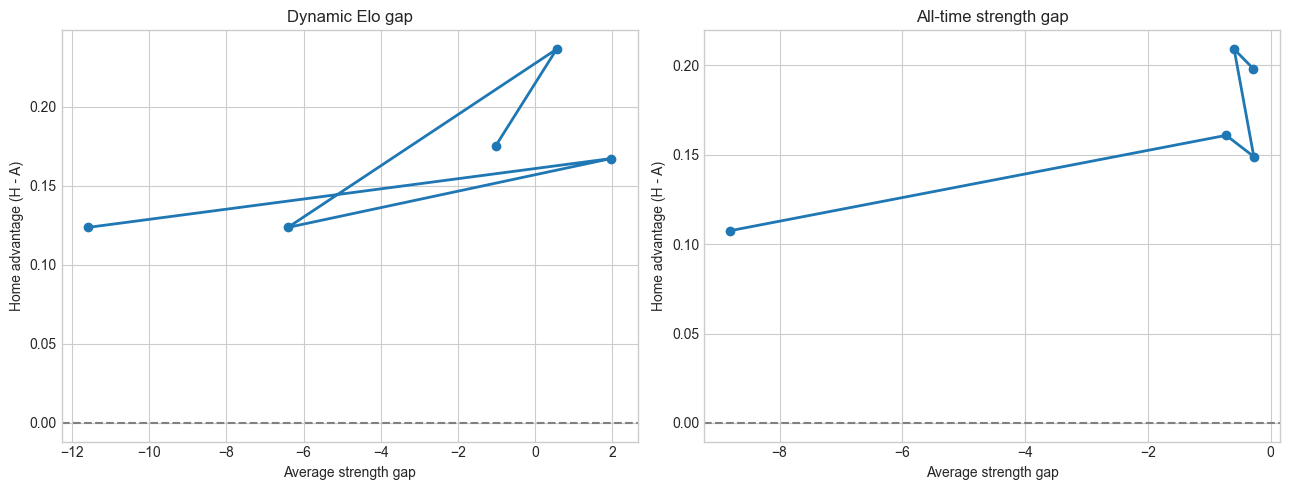

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, table, title in [
    (axes[0], elo_gap_summary, "Dynamic Elo gap"),
    (axes[1], alltime_gap_summary, "All-time strength gap"),
]:
    ax.plot(table["mean_gap"], table["home_minus_away"], marker="o", linewidth=2)
    ax.axhline(0, linestyle="--", color="gray")
    ax.set_xlabel("Average strength gap")
    ax.set_ylabel("Home advantage (H - A)")
    ax.set_title(title)
fig.tight_layout()
plt.show()


## 4. بررسی خانه/مهمان در تیم‌های قوی‌تر و ضعیف‌تر

In [8]:
analysis["home_team_stronger"] = analysis["alltime_elo_proxy_diff"] > 0
analysis["away_team_stronger"] = analysis["alltime_elo_proxy_diff"] < 0
team_strength_group = analysis.groupby("home_team_stronger").agg(
    matches=("result", "size"),
    home_win_rate=("home_win", "mean"),
    away_win_rate=("away_win", "mean"),
    draw_rate=("draw", "mean"),
).reset_index()
team_strength_group["group"] = np.where(team_strength_group["home_team_stronger"], "Home team stronger", "Away team stronger")
team_strength_group


,home_team_stronger,matches,home_win_rate,away_win_rate,draw_rate,group
0,False,884,0.274887,0.458145,0.266968,Away team stronger
1,True,854,0.667447,0.141686,0.190867,Home team stronger


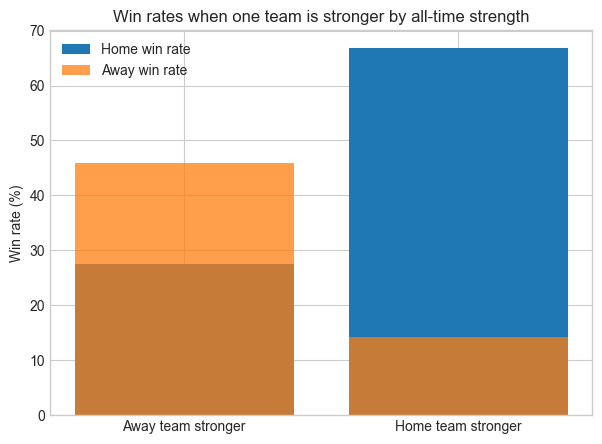

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(team_strength_group["group"], team_strength_group["home_win_rate"] * 100, label="Home win rate")
ax.bar(team_strength_group["group"], team_strength_group["away_win_rate"] * 100, label="Away win rate", alpha=0.75)
ax.set_ylabel("Win rate (%)")
ax.set_title("Win rates when one team is stronger by all-time strength")
ax.legend()
plt.show()


## 5. نتیجه‌گیری تحلیلی

در مسابقات با اختلاف قدرت کم، مزیت خانه بیشتر دیده می‌شود. با افزایش برتری یک تیم، تعادل واقعی بازی بیشتر به نفع آن تیم می‌چرخد و اثر مزیت خانه رو به کاهش می‌گذارد. این نتیجه با منطق Elo و قدرت تیم‌ها هم‌خوانی دارد: مزیت خانه یک اثر تعدیل‌کننده است، اما وقتی تیم میزبان یا مهمان از نظر رتبه و قدرت اختلاف واضح دارد، این اثر تضعیف می‌شود.